# VQE Tutorial (OpenVQA)

Runs VQE on H2 with COBYLA, BFGS, Adam (from `openvqa/mathematical_tools/adam_optimizer.py`), and a second ansatz.

In [1]:
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on sys.path (so import openvqa works when running from openvqa/tutorial)
sys.path.insert(0, os.path.abspath('../..'))

# IMPORTANT: force Python to use this workspace's OpenVQA code
# (so changes like the Adam integration in openvqa/algorithms/vqe.py take effect).
for name in list(sys.modules.keys()):
    if name == 'openvqa' or name.startswith('openvqa.'):
        del sys.modules[name]

from openvqa import VQA_myQLM
from openvqa.algorithms import VQE
import openvqa as _openvqa

print('✓ OpenVQA imported from:', os.path.dirname(_openvqa.__file__))
print('  NumPy:', np.__version__)

c:\Users\kshit\anaconda3\envs\vqa\lib\site-packages\qat\interop\__init__.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


✓ OpenVQA imported from: d:\open_vqa\openvqa
  NumPy: 1.26.4


In [2]:
engine = VQA_myQLM(
    n_qubits=2,
    backend='qat.simulators.qubit',
    shots=1000,
    seed=42,
    verbose=False
)

print('✓ VQA Engine initialized')

✓ VQA Engine initialized


In [88]:
vqe_cobyla = VQE(
    hamiltonian='H2',
    ansatz='RealAmplitudes',
    optimizer='cobyla',
    max_iterations=50,
    n_layers=2,
)
print('Running VQE (COBYLA)...')
results_cobyla = engine.run(vqe_cobyla)
print('Energy:', results_cobyla.energy)
print('Time (s):', results_cobyla.wall_time)

Running VQE (COBYLA)...
Energy: -0.49990194825817175
Time (s): 0.8092796802520752


In [89]:
vqe_bfgs = VQE(
    hamiltonian='H2',
    ansatz='RealAmplitudes',
    optimizer='bfgs',
    max_iterations=50,
    n_layers=2,
)
print('Running VQE (BFGS)...')
results_bfgs = engine.run(vqe_bfgs)
print('Energy:', results_bfgs.energy)
print('Time (s):', results_bfgs.wall_time)

Running VQE (BFGS)...
Energy: -0.49999999999933625
Time (s): 1.3773472309112549


In [90]:
vqe_adam = VQE(
    hamiltonian='H2',
    ansatz='RealAmplitudes',
    optimizer='adam',
    max_iterations=50,
    n_layers=2,
    optimizer_options={'learning_rate': 0.01},
)
print('Running VQE (Adam)...')
results_adam = engine.run(vqe_adam)
print('Energy:', results_adam.energy)
print('Time (s):', results_adam.wall_time)

Running VQE (Adam)...
Energy: -0.2613081204230025
Time (s): 2.3077101707458496


In [91]:
vqe_efficient = VQE(
    hamiltonian='H2',
    ansatz='EfficientSU2',
    optimizer='cobyla',
    max_iterations=50,
    n_layers=2,
)
print('Running VQE (EfficientSU2 + COBYLA)...')
results_efficient = engine.run(vqe_efficient)
print('Energy:', results_efficient.energy)
print('Time (s):', results_efficient.wall_time)

Running VQE (EfficientSU2 + COBYLA)...
Energy: -0.48867158448760684
Time (s): 0.8649559020996094


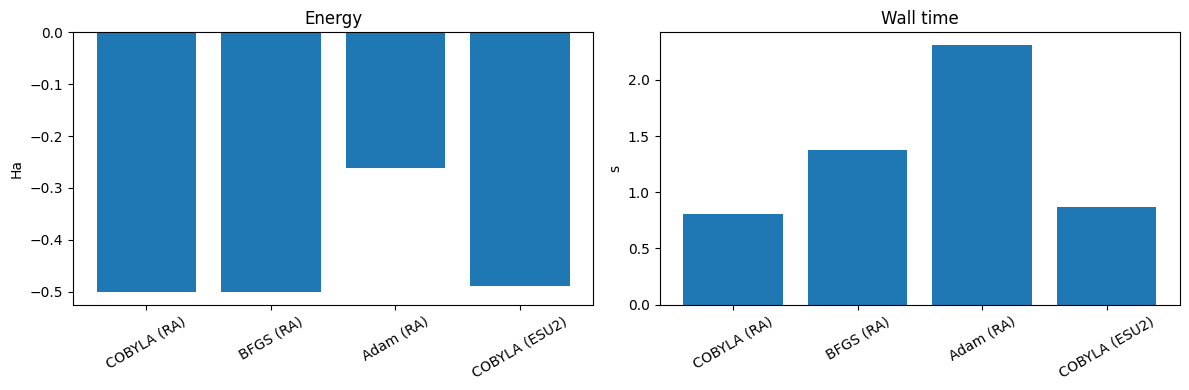

In [93]:
%matplotlib inline

labels = ['COBYLA (RA)', 'BFGS (RA)', 'Adam (RA)', 'COBYLA (ESU2)']
energies = [results_cobyla.energy, results_bfgs.energy, results_adam.energy, results_efficient.energy]
times = [results_cobyla.wall_time, results_bfgs.wall_time, results_adam.wall_time, results_efficient.wall_time]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(labels, energies)
ax1.set_title('Energy')
ax1.set_ylabel('Ha')
ax1.tick_params(axis='x', rotation=30)

ax2.bar(labels, times)
ax2.set_title('Wall time')
ax2.set_ylabel('s')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Examples / full demo cases

If you want to try a more complete set of configurations (different backends, ansatz choices, and data-encoding choices), run the example notebook:

- `openvqa/examples/vqe_demo.ipynb`

Recommended things to try inside that example notebook:

- **Ansatz**: Qiskit (`RealAmplitudes`, `EfficientSU2`, `TwoLocal`) and different `n_layers`.
- **Feature map / embedding** (if you use data encoding): Qiskit feature maps (`PauliFeatureMap`, `ZZFeatureMap`, `ZFeatureMap`) and PennyLane embeddings (`AngleEmbedding`, `AmplitudeEmbedding`, `BasisEmbedding`, `DisplacementEmbedding`).
- **Optimizer**: compare `cobyla`, `bfgs`, `nelder-mead`, `adam` with the same Hamiltonian + ansatz.
- **Iteration budget**: increase `max_iterations` as you increase `n_layers` (more parameters usually needs more optimization effort).
- **Adam hyperparameters**: tune `learning_rate`, `beta1`, `beta2` (and compare against BFGS/COBYLA).